# Welcome to Colab!

## Google Colab is available in VS Code!
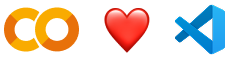

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## 3_2_qwen3_colab_deploy


In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [7]:
!nvidia-smi

Sat Jun  6 14:26:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             29W /   70W |    7643MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -U transformers accelerate torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/

In [2]:
!pip uninstall -y torchvision
!pip install -U transformers accelerate torch

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    dtype=torch.float16,
)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors.index.json:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

In [2]:
def run_inference(user_input: str, max_tokens: int = 128):
    messages = [
        {"role": "user", "content": f"请解释以下中文成语的含义与出处：{user_input}"}
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.8,
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

for idiom in ["画蛇添足", "纸上谈兵", "掩耳盗铃"]:
    print(f"\n")
    print(run_inference(idiom))



<think>
嗯，用户让我解释“画蛇添足”的成语含义和出处。首先，我需要确认这个成语的正确解释。画蛇添足的故事出自《战国策》，对吧？我记得是关于一个楚国的使者，他给蛇画了脚，结果反而让蛇变得不完美，所以后来用这个成语来比喻多此一举，做了不必要的事情。

接下来，我得确保自己理解正确。故事中的使者可能是在给蛇画脚，结果反而让蛇变得不协调，所以后来用“画蛇添足”来比喻多此一举。不过，可能用户想知道


<think>
嗯，用户让我解释“纸上谈兵”的成语含义和出处。首先，我需要确认这个成语的正确性。我记得“纸上谈兵”确实是一个常见的成语，用来比喻空谈理论，不切实际。但我要确保自己记得准确，可能需要查证一下。

接下来，我得想想这个成语的出处。通常，这个成语的来源可能和古代的典故有关。比如，战国时期的赵国名将廉颇和蔺相如的故事。廉颇因为不服气蔺相如的职位，多次挑衅，但蔺相如总是回避，廉颇于是觉得不


<think>
嗯，用户让我解释“掩耳盗铃”的成语含义和出处。首先，我需要确认这个成语的正确性。掩耳盗铃听起来像是一个自欺欺人的故事，但可能用户记错了，比如“掩耳盗铃”是否正确？或者是不是“掩耳盗铃”？不过根据常见的成语，应该是正确的。

接下来，我得回忆这个成语的故事。通常讲的是一个人想偷铃铛，但捂住自己的耳朵，以为别人听不到，但实际上别人还是能听见。这个故事出自《吕氏春秋》，不过可能有不同的版本。需要确认出处是否正确


## 3_3_qwen3_lora_colab_finetune

In [2]:
!pip uninstall -y torchvision torchao
!pip install -U torch transformers accelerate datasets peft

In [3]:
import torch
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

MODEL_ID = "Qwen/Qwen3-1.7B"
OUTPUT_DIR = "./output/qwen3_lora_sentiment"


In [4]:
def load_model_and_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map="auto",
        dtype=torch.float16,
    )
    model.config.use_cache = False
    return model, tokenizer


def build_dataset():
    data = [
        {"text": "客服态度很好，处理问题及时", "label": "正面"},
        {"text": "屏幕亮度太低，看起来很费眼", "label": "负面"},
        {"text": "物流太快了，包装也非常结实", "label": "正面"},
        {"text": "使用几天就死机了，非常糟糕", "label": "负面"},
        {"text": "价格优惠，功能也很全面", "label": "正面"},
        {"text": "音质不清晰，续航时间短", "label": "负面"},
    ]
    return Dataset.from_list(data)


def format_training_text(sample, tokenizer):
    messages = [
        {
            "role": "system",
            "content": "你是一个中文情感分类助手，只回答“正面”或“负面”。",
        },
        {
            "role": "user",
            "content": f"请判断以下句子的情感倾向：{sample['text']}",
        },
        {
            "role": "assistant",
            "content": sample["label"],
        },
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )


def tokenize_dataset(dataset, tokenizer):
    def preprocess(sample):
        text = format_training_text(sample, tokenizer)
        tokenized = tokenizer(
            text,
            truncation=True,
            max_length=256,
            padding=False,
        )
        tokenized["labels"] = tokenized["input_ids"].copy()
        return tokenized

    return dataset.map(preprocess, remove_columns=dataset.column_names)


def build_lora_model(base_model):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
    )
    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()
    return model


In [5]:
def train():
    model, tokenizer = load_model_and_tokenizer()
    model = build_lora_model(model)

    dataset = build_dataset()
    tokenized_dataset = tokenize_dataset(dataset, tokenizer)

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False,
    )

    train_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        num_train_epochs=3,
        logging_steps=1,
        save_strategy="epoch",
        learning_rate=2e-4,
        fp16=True,
        report_to="none",
        remove_unused_columns=False,
    )

    trainer = Trainer(
        model=model,
        args=train_args,
        train_dataset=tokenized_dataset,
        data_collator=data_collator,
    )

    trainer.train()
    model.save_pretrained(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print(f">>> LoRA权重已保存到：{OUTPUT_DIR}")

In [6]:
if __name__ == "__main__":
    if not torch.cuda.is_available():
        raise RuntimeError("未检测到CUDA GPU。请在Colab中启用 Runtime > Change runtime type > T4 GPU。")
    print(">>> CUDA GPU:", torch.cuda.get_device_name(0))
    train()

>>> CUDA GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

trainable params: 8,716,288 || all params: 1,729,291,264 || trainable%: 0.5040


Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Step,Training Loss
1,6.710687
2,5.430216
3,4.588071
4,4.170899
5,3.825139
6,3.491615


>>> LoRA权重已保存到：./output/qwen3_lora_sentiment


In [7]:
test_samples = [
    {"text": "包装破损，客服也没人处理", "label": "负面"},
    {"text": "外观漂亮，运行速度也很快", "label": "正面"},
    {"text": "电池不耐用，发热明显", "label": "负面"},
    {"text": "价格合理，体验超出预期", "label": "正面"},
    {"text": "用了两天就坏了，很失望", "label": "负面"},
    {"text": "安装简单，功能也很实用", "label": "正面"},
]

In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

MODEL_ID = "Qwen/Qwen3-1.7B"
LORA_DIR = "./output/qwen3_lora_sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    dtype=torch.float16,
)

model = PeftModel.from_pretrained(base_model, LORA_DIR)
model.eval()

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-27): 28 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(


In [9]:
def predict_sentiment(text: str) -> str:
    messages = [
        {
            "role": "system",
            "content": "你是一个中文情感分类助手，只回答“正面”或“负面”。",
        },
        {
            "role": "user",
            "content": f"请判断以下句子的情感倾向：{text}",
        },
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    if "正面" in answer:
        return "正面"
    if "负面" in answer:
        return "负面"
    return answer

In [10]:
correct = 0

for item in test_samples:
    pred = predict_sentiment(item["text"])
    ok = pred == item["label"]
    correct += int(ok)

    print(f"文本：{item['text']}")
    print(f"预测：{pred} | 标注：{item['label']} | {'✓' if ok else '✗'}")
    print()

accuracy = correct / len(test_samples)
print(f"准确率：{accuracy:.2%}")

文本：包装破损，客服也没人处理
预测：<think>
好的，我现在需要判断用户 | 标注：负面 | ✗

文本：外观漂亮，运行速度也很快
预测：<think>
好的，我现在需要判断用户 | 标注：正面 | ✗

文本：电池不耐用，发热明显
预测：<think>
好的，我现在需要判断用户 | 标注：负面 | ✗

文本：价格合理，体验超出预期
预测：<think>
好的，我现在需要判断用户 | 标注：正面 | ✗

文本：用了两天就坏了，很失望
预测：<think>
好的，我现在需要判断用户 | 标注：负面 | ✗

文本：安装简单，功能也很实用
预测：<think>
好的，我现在需要判断用户 | 标注：正面 | ✗

准确率：0.00%
